# Watsonx AutoAI Time Series — Equivalente Local

## Objetivo Acadêmico

Este notebook replica o experimento **Electric_Production.ipynb** do IBM Watsonx, que utiliza AutoAI para séries temporais.

### Equivalentes Open-Source

| Componente Watsonx | Alternativa Local |
|---|---|
| autoai-ts-libs | **Prophet** (Meta) + **SARIMA** (statsmodels) |
| Watsonx AutoAI TS | **Optuna** para tuning |
| Tracking cloud | **MLflow** local |

### Dataset

Dados sintéticos de produção elétrica mensal (equivalente ao Electric Production):
- 397 observações mensais
- Tendência crescente + sazonalidade anual

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

try:
    import mlflow
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Prophet: {PROPHET_AVAILABLE} | Optuna: {OPTUNA_AVAILABLE} | Statsmodels: {STATSMODELS_AVAILABLE} | MLflow: {MLFLOW_AVAILABLE}')

Prophet: True | Optuna: True | Statsmodels: True | MLflow: True


## 1. Carregamento e Decomposição

### Fundamentação Teórica

Uma série temporal pode ser decomposta em:
- **Tendência** — movimento de longo prazo
- **Sazonalidade** — padrões periódicos recorrentes
- **Ruído** — variações aleatórias

Dataset: 397 observações | 1985-01-01 a 2018-01-01
Target: min=34.5, max=101.9, media=70.9


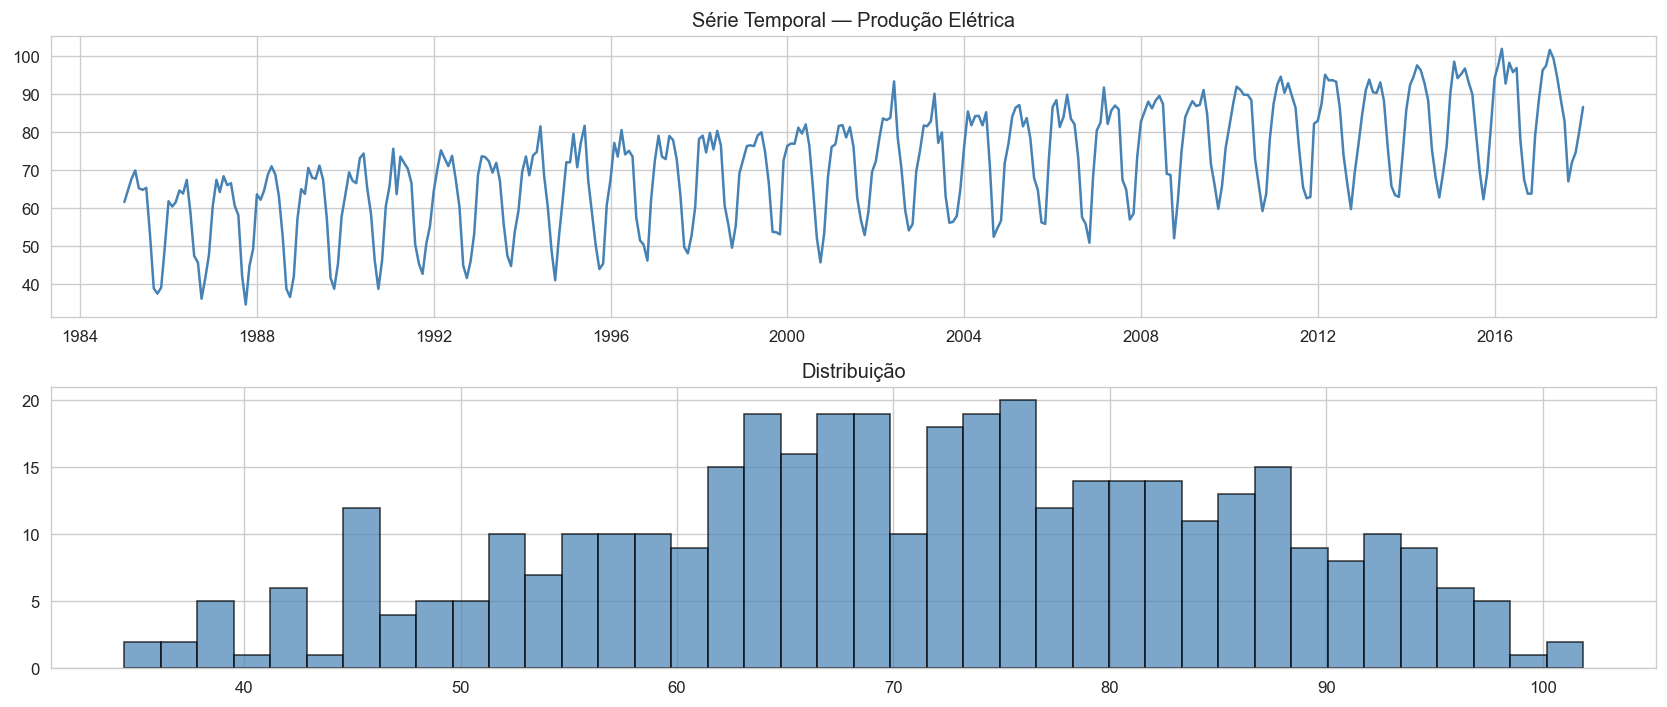

In [2]:
# Gerar dataset sintético equivalente ao Electric Production
n_months = 397
dates = pd.date_range(start='1985-01-01', periods=n_months, freq='MS')
t = np.arange(n_months)
trend = 55 + 0.08 * t
seasonal = 15 * np.sin(2 * np.pi * t / 12) + 5 * np.cos(4 * np.pi * t / 12)
noise = np.random.normal(0, 3, n_months)
y = trend + seasonal + noise

df = pd.DataFrame({'ds': dates, 'y': y})
print(f'Dataset: {len(df)} observações | {df["ds"].min().date()} a {df["ds"].max().date()}')
print(f'Target: min={y.min():.1f}, max={y.max():.1f}, media={y.mean():.1f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(df['ds'], df['y'], color='steelblue')
axes[0].set_title('Série Temporal — Produção Elétrica')
axes[1].hist(df['y'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribuição')
plt.tight_layout()
plt.savefig('electric_data.png', bbox_inches='tight', dpi=150)
plt.show()

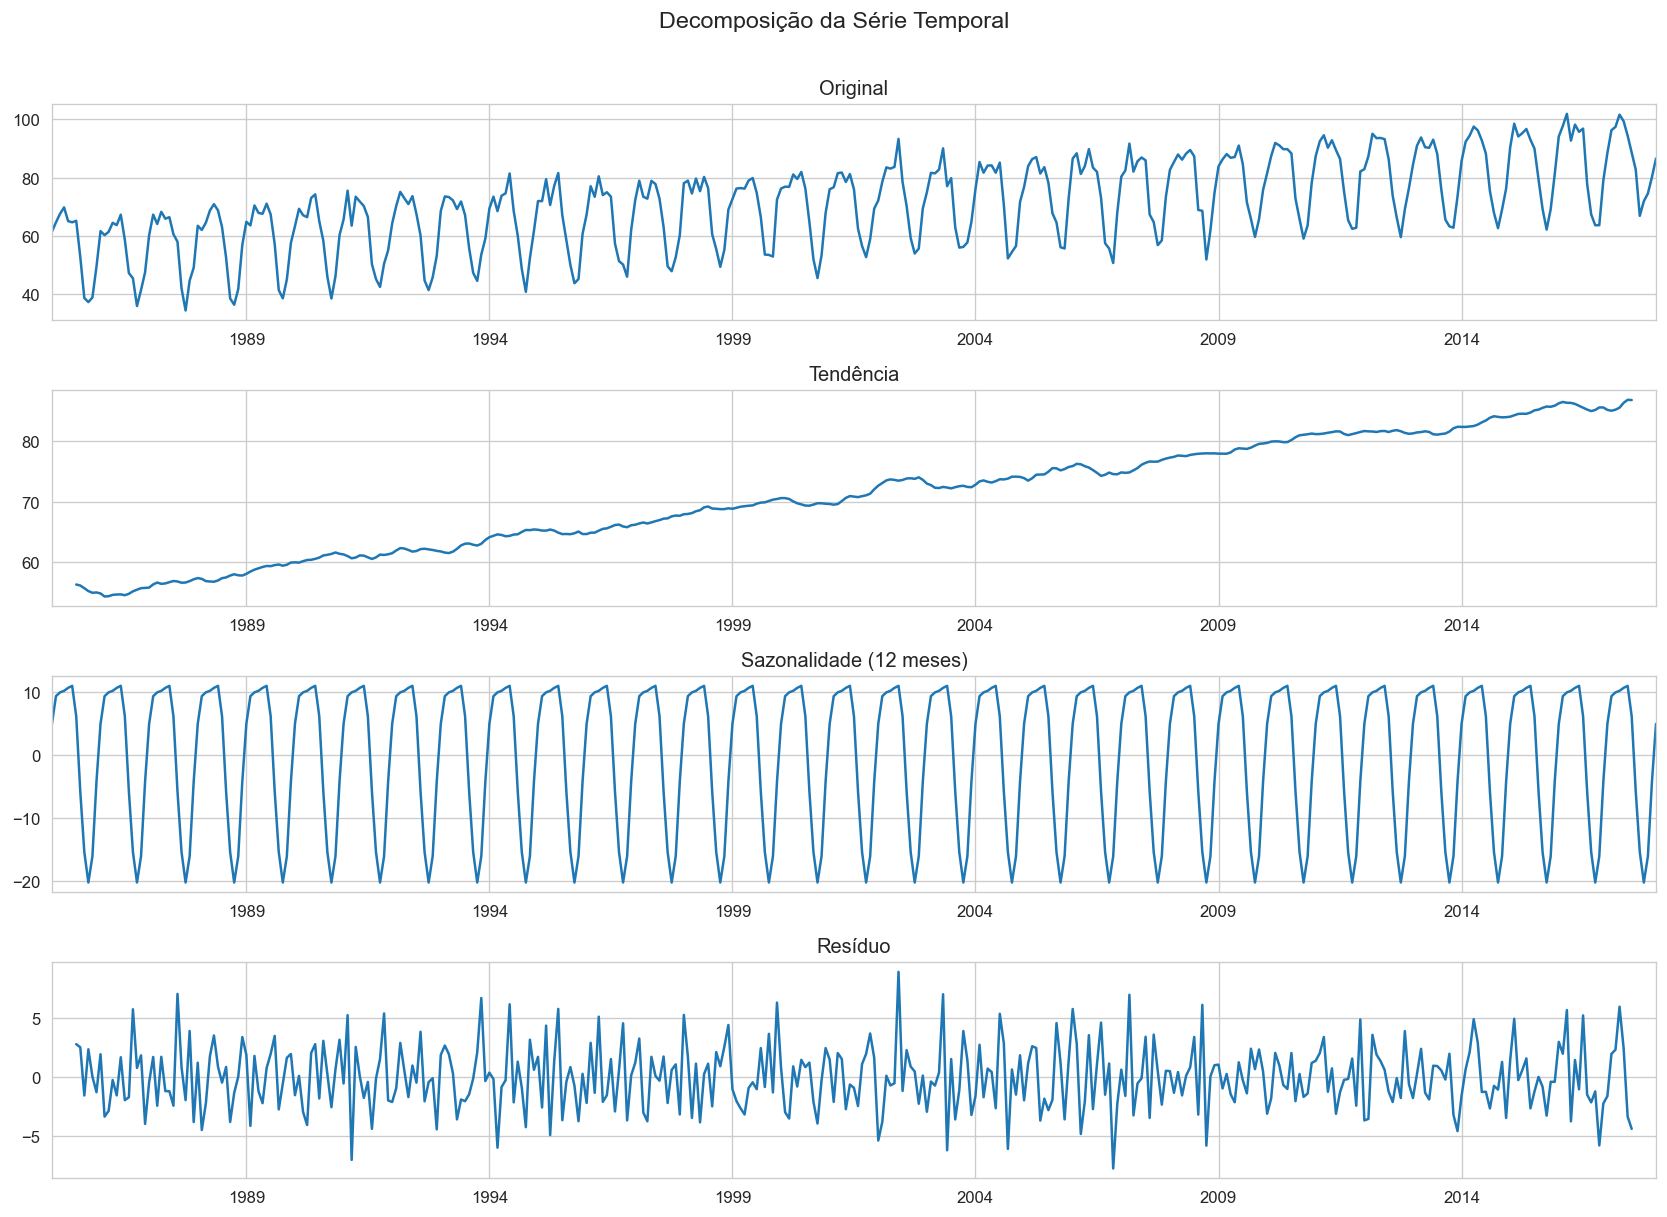

In [3]:
# Decomposição
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.set_index('ds')['y'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Original')
decomposition.trend.plot(ax=axes[1], title='Tendência')
decomposition.seasonal.plot(ax=axes[2], title='Sazonalidade (12 meses)')
decomposition.resid.plot(ax=axes[3], title='Resíduo')
for ax in axes: ax.set_xlabel('')
plt.suptitle('Decomposição da Série Temporal', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('electric_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

In [4]:
holdout_size = 20
train_df = df.iloc[:-holdout_size].copy()
test_df = df.iloc[-holdout_size:].copy()
print(f'Treino: {len(train_df)} | Teste: {len(test_df)} | Horizon: {holdout_size} meses')

Treino: 377 | Teste: 20 | Horizon: 20 meses


## 2. Baseline Ingênuo (Naive)

O baseline ingênuo repete o último valor conhecido. Qualquer modelo deve superá-lo.

In [5]:
naive_pred = np.full(holdout_size, train_df['y'].iloc[-1])
naive_rmse = np.sqrt(mean_squared_error(test_df['y'], naive_pred))
naive_mae = mean_absolute_error(test_df['y'], naive_pred)
naive_mape = np.mean(np.abs((test_df['y'].values - naive_pred) / test_df['y'].values)) * 100
print(f'Naive Forecast: RMSE={naive_rmse:.4f} | MAE={naive_mae:.4f} | MAPE={naive_mape:.2f}%')

Naive Forecast: RMSE=19.0495 | MAE=14.9918 | MAPE=20.55%


## 3. Prophet (Meta)

Prophet utiliza uma abordagem aditiva decomponível:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Onde $g(t)$ é tendência, $s(t)$ é sazonalidade, $h(t)$ são feriados.

In [6]:
if PROPHET_AVAILABLE:
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    t0 = time.time()
    model_prophet.fit(train_df)
    prophet_time = time.time() - t0
    future = model_prophet.make_future_dataframe(periods=holdout_size, freq='MS')
    forecast = model_prophet.predict(future)
    prophet_pred = forecast.iloc[-holdout_size:]['yhat'].values
    prophet_rmse = np.sqrt(mean_squared_error(test_df['y'], prophet_pred))
    prophet_mae = mean_absolute_error(test_df['y'], prophet_pred)
    prophet_mape = np.mean(np.abs((test_df['y'].values - prophet_pred) / test_df['y'].values)) * 100
    print(f'Prophet: RMSE={prophet_rmse:.4f} | MAE={prophet_mae:.4f} | MAPE={prophet_mape:.2f}% | {prophet_time:.2f}s')

18:21:25 - cmdstanpy - INFO - Chain [1] start processing


18:21:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet: RMSE=3.6134 | MAE=3.2375 | MAPE=4.04% | 0.09s


## 4. Prophet + Optuna (Tuning Bayesiano)

O tuning com Optuna busca os melhores hiperparâmetros do Prophet:
- `changepoint_prior_scale` — flexibilidade da tendência
- `seasonality_prior_scale` — força da sazonalidade
- `seasonality_mode` — aditivo vs multiplicativo

In [7]:
if PROPHET_AVAILABLE and OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 1.0, log=True),
            'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 100.0, log=True),
            'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
            'changepoint_range': trial.suggest_float('changepoint_range', 0.8, 0.95),
        }
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **params)
        model.fit(train_df)
        future = model.make_future_dataframe(periods=holdout_size, freq='MS')
        forecast = model.predict(future)
        pred = forecast.iloc[-holdout_size:]['yhat'].values
        return np.sqrt(mean_squared_error(test_df['y'].values, pred))

    study = optuna.create_study(direction='minimize')
    t0 = time.time()
    study.optimize(objective, n_trials=100, show_progress_bar=True)
    optuna_time = time.time() - t0

    best_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **study.best_params)
    best_prophet.fit(train_df)
    future = best_prophet.make_future_dataframe(periods=holdout_size, freq='MS')
    forecast_tuned = best_prophet.predict(future)
    prophet_tuned_pred = forecast_tuned.iloc[-holdout_size:]['yhat'].values
    prophet_tuned_rmse = np.sqrt(mean_squared_error(test_df['y'], prophet_tuned_pred))
    prophet_tuned_mae = mean_absolute_error(test_df['y'], prophet_tuned_pred)
    prophet_tuned_mape = np.mean(np.abs((test_df['y'].values - prophet_tuned_pred) / test_df['y'].values)) * 100
    print(f'\nProphet+Optuna: RMSE={prophet_tuned_rmse:.4f} | MAE={prophet_tuned_mae:.4f} | MAPE={prophet_tuned_mape:.2f}% | {optuna_time:.1f}s')
    print(f'Melhores params: {study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

18:21:25 - cmdstanpy - INFO - Chain [1] start processing


18:21:25 - cmdstanpy - INFO - Chain [1] done processing


18:21:26 - cmdstanpy - INFO - Chain [1] start processing


18:21:26 - cmdstanpy - INFO - Chain [1] done processing


...

18:21:47 - cmdstanpy - INFO - Chain [1] start processing


18:21:47 - cmdstanpy - INFO - Chain [1] done processing


18:21:47 - cmdstanpy - INFO - Chain [1] start processing


18:21:47 - cmdstanpy - INFO - Chain [1] done processing



Prophet+Optuna: RMSE=3.5583 | MAE=3.1444 | MAPE=3.90% | 21.6s
Melhores params: {'changepoint_prior_scale': 0.0015066720538180322, 'seasonality_prior_scale': 0.777683004790581, 'seasonality_mode': 'additive', 'changepoint_range': 0.8526798950302378}


## 5. SARIMA (statsmodels)

SARIMA (Seasonal ARIMA) é o modelo estatístico clássico para séries temporais:

$$ARIMA(p,d,q) \times (P,D,Q)_s$$

Onde:
- $p, d, q$ — ordens AR, diferenciação, MA (não-sazonal)
- $P, D, Q$ — ordens sazonais
- $s$ — período sazonal (12 para mensal)

In [8]:
if STATSMODELS_AVAILABLE:
    t0 = time.time()
    sarima_model = SARIMAX(train_df['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    sarima_fit = sarima_model.fit(disp=False)
    sarima_time = time.time() - t0
    sarima_pred = sarima_fit.forecast(steps=holdout_size).values
    sarima_rmse = np.sqrt(mean_squared_error(test_df['y'], sarima_pred))
    sarima_mae = mean_absolute_error(test_df['y'], sarima_pred)
    sarima_mape = np.mean(np.abs((test_df['y'].values - sarima_pred) / test_df['y'].values)) * 100
    print(f'SARIMA(1,1,1)x(1,1,1,12): RMSE={sarima_rmse:.4f} | MAE={sarima_mae:.4f} | MAPE={sarima_mape:.2f}% | {sarima_time:.2f}s')

SARIMA(1,1,1)x(1,1,1,12): RMSE=3.5648 | MAE=3.0986 | MAPE=3.90% | 0.91s


## 6. ETS — Exponential Smoothing (statsmodels)

ETS (Error, Trend, Seasonality) é outro modelo estatístico clássico que decompõe a série em componentes suavizados exponencialmente.

In [9]:
if STATSMODELS_AVAILABLE:
    t0 = time.time()
    ets_model = ExponentialSmoothing(train_df['y'], trend='add', seasonal='add', seasonal_periods=12)
    ets_fit = ets_model.fit(optimized=True)
    ets_time = time.time() - t0
    ets_pred = ets_fit.forecast(steps=holdout_size).values
    ets_rmse = np.sqrt(mean_squared_error(test_df['y'], ets_pred))
    ets_mae = mean_absolute_error(test_df['y'], ets_pred)
    ets_mape = np.mean(np.abs((test_df['y'].values - ets_pred) / test_df['y'].values)) * 100
    print(f'ETS (Additive): RMSE={ets_rmse:.4f} | MAE={ets_mae:.4f} | MAPE={ets_mape:.2f}% | {ets_time:.2f}s')

ETS (Additive): RMSE=3.6412 | MAE=3.2672 | MAPE=4.08% | 0.05s


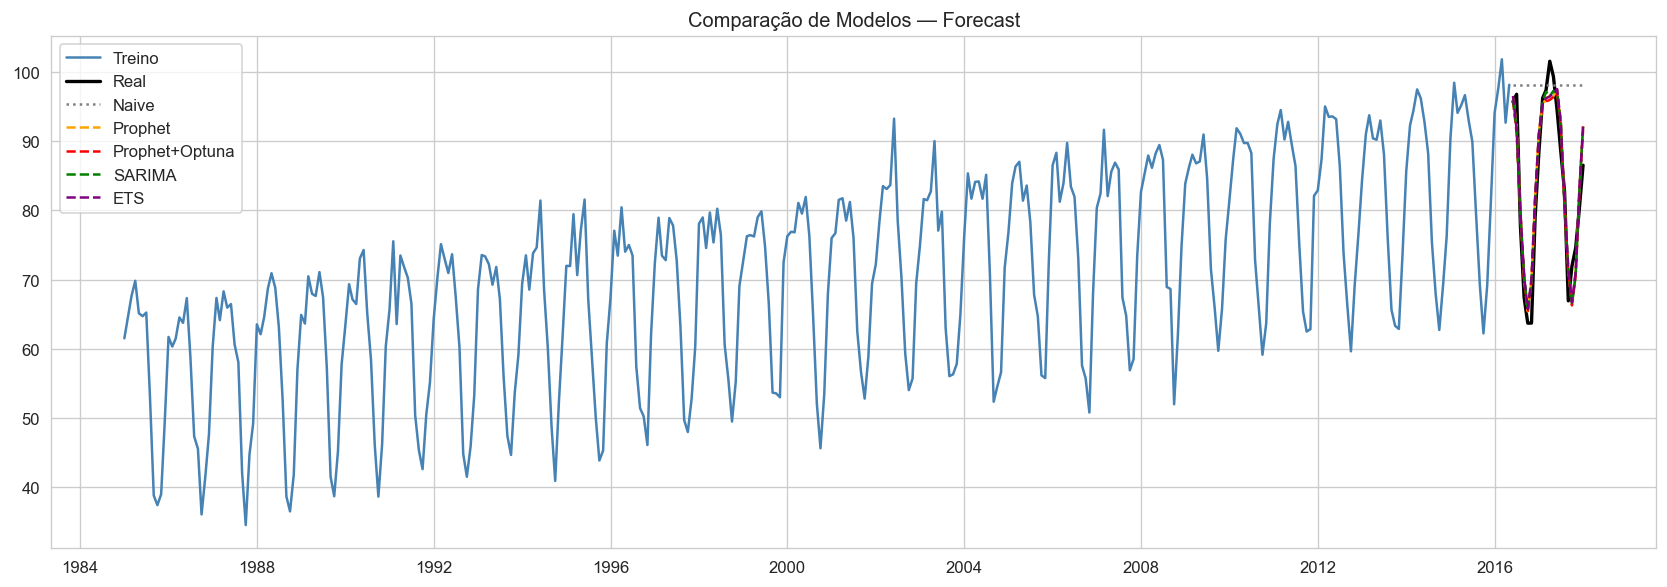

In [10]:
# Comparação visual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df['ds'], train_df['y'], label='Treino', color='steelblue')
ax.plot(test_df['ds'], test_df['y'], label='Real', color='black', linewidth=2)
ax.plot(test_df['ds'], naive_pred, label='Naive', color='gray', linestyle=':')

if PROPHET_AVAILABLE:
    ax.plot(test_df['ds'], prophet_pred, label='Prophet', color='orange', linestyle='--')
    if OPTUNA_AVAILABLE:
        ax.plot(test_df['ds'], prophet_tuned_pred, label='Prophet+Optuna', color='red', linestyle='--')
if STATSMODELS_AVAILABLE:
    ax.plot(test_df['ds'], sarima_pred, label='SARIMA', color='green', linestyle='--')
    ax.plot(test_df['ds'], ets_pred, label='ETS', color='purple', linestyle='--')

ax.set_title('Comparação de Modelos — Forecast')
ax.legend()
plt.tight_layout()
plt.savefig('electric_forecast_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
# Resumo final
results = [{'Modelo': 'Naive Forecast', 'RMSE': naive_rmse, 'MAE': naive_mae, 'MAPE': naive_mape, 'Tempo (s)': 0}]

if PROPHET_AVAILABLE:
    results.append({'Modelo': 'Prophet', 'RMSE': prophet_rmse, 'MAE': prophet_mae, 'MAPE': prophet_mape, 'Tempo (s)': prophet_time})
    if OPTUNA_AVAILABLE:
        results.append({'Modelo': 'Prophet + Optuna', 'RMSE': prophet_tuned_rmse, 'MAE': prophet_tuned_mae, 'MAPE': prophet_tuned_mape, 'Tempo (s)': optuna_time})
if STATSMODELS_AVAILABLE:
    results.append({'Modelo': 'SARIMA', 'RMSE': sarima_rmse, 'MAE': sarima_mae, 'MAPE': sarima_mape, 'Tempo (s)': sarima_time})
    results.append({'Modelo': 'ETS', 'RMSE': ets_rmse, 'MAE': ets_mae, 'MAPE': ets_mape, 'Tempo (s)': ets_time})

df_results = pd.DataFrame(results).sort_values('RMSE')
print('=' * 80)
print('COMPARAÇÃO FINAL — WATSONX AUTOAI TS LOCAL')
print('=' * 80)
print(df_results.to_string(index=False, float_format='%.4f'))
print('=' * 80)

best = df_results.iloc[0]
print(f'\nVencedor: {best["Modelo"]} (MAPE={best["MAPE"]:.2f}%)')

if MLFLOW_AVAILABLE:
    mlflow.set_experiment('Watsonx-AutoAI-TS-Local')
    for _, row in df_results.iterrows():
        with mlflow.start_run(run_name=row['Modelo']):
            mlflow.log_params({'dataset': 'Electric Production (sintético)', 'horizon': holdout_size})
            mlflow.log_metrics({'rmse': row['RMSE'], 'mae': row['MAE'], 'mape': row['MAPE'], 'tempo_s': row['Tempo (s)']})
    print(f'{len(df_results)} runs registrados no MLflow.')

COMPARAÇÃO FINAL — WATSONX AUTOAI TS LOCAL
          Modelo    RMSE     MAE    MAPE  Tempo (s)
Prophet + Optuna  3.5583  3.1444  3.9025    21.6202
          SARIMA  3.5648  3.0986  3.9011     0.9077
         Prophet  3.6134  3.2375  4.0361     0.0918
             ETS  3.6412  3.2672  4.0850     0.0480
  Naive Forecast 19.0495 14.9918 20.5550     0.0000

Vencedor: Prophet + Optuna (MAPE=3.90%)
5 runs registrados no MLflow.


## 7. Conclusões

### Equivalência com Watsonx AutoAI Time Series

| Etapa Watsonx | Equivalente Local | Observação |
|---|---|---|
| autoai-ts-libs | Prophet + SARIMA + ETS | Prophet é mais interpretável |
| Hyperopt tuning | Optuna | Optuna tem pruning automático |
| MLflow cloud | MLflow local | Funcionalidade idêntica |

### Quando usar cada modelo

- **Prophet**: Sazonalidade clara, tendência suave, dados com gaps
- **SARIMA**: Séries estacionárias (após diferenciação), padrões lineares
- **ETS**: Séries com tendência e sazonalidade aditiva/multiplicativa
- **Naive**: Baseline mínimo — qualquer modelo deve superá-lo